In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import fetch_california_housing
from joblib import dump
import math
from scipy.io import loadmat

import matplotlib.pyplot as plt


In [ ]:
#read a matlab struct from a mat file and save it into a pd dataframe

mat = loadmat('./microstructures_object_array_final.mat')
raw_rows = mat['final_microstructure_array'][0]

column_names = raw_rows[0].dtype.names

data = []

for raw_row in raw_rows:
    row=[]
    for array in raw_row:
        if len(array[0]) == 1:
            row.append(array[0][0])
        else:
            row.append(array[0])

    data.append(row)

data

df =  pd.DataFrame(data, columns= column_names )


num_rows = df.shape[0]

# Separate the last 5 rows into a validation set
validation_df = df.iloc[num_rows - 6:]

# The rest of the rows go into the training set
training_df = df.iloc[:num_rows - 6]

df = training_df

validation_df

df["R11"] = df["yield_stress_XX"]/df["yield_stress_ZZ"]

print(training_df["yield_stress_hardening_ZZ"].values)

[array([ 839.14530808,  879.63585274,  914.63522551,  945.77655216,
         974.56907264, 1001.89078888, 1027.56807297, 1050.66693348,
        1070.03113407, 1086.02889608, 1098.93032116, 1109.6092765 ,
        1118.80013935, 1126.71080385, 1134.18048134, 1140.70720324,
        1146.80146014, 1152.47854023, 1157.47279506, 1162.41882529,
        1166.6027822 , 1170.68977706, 1174.47474293, 1177.78194177,
        1181.22923001, 1183.93178471, 1186.76936927, 1189.31946972,
        1191.58903167, 1194.07105594, 1195.85657613, 1197.94222706,
        1199.6945078 , 1201.35314441, 1203.17764039, 1204.45430134,
        1206.10154371, 1207.32530923, 1208.63398117, 1210.00825511,
        1210.99236996, 1212.38254125, 1213.23407156, 1214.34623411,
        1215.3867793 , 1216.21038767, 1217.44782315, 1218.02247517,
        1219.03058655, 1219.80589878, 1220.55332893, 1221.55793691,
        1222.05947317, 1223.01941484, 1223.57290239, 1224.29919442,
        1225.09432044, 1225.57930611, 1226.52272

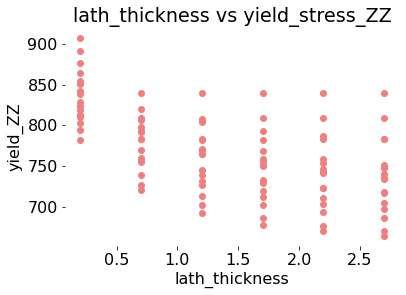

In [125]:
plt.scatter(df['lath_thickness'], df['yield_stress_ZZ'], color = 'lightcoral')
plt.title('lath_thickness vs yield_stress_ZZ')
plt.xlabel('lath_thickness')
plt.ylabel('yield_ZZ')
plt.box(False)
plt.show()



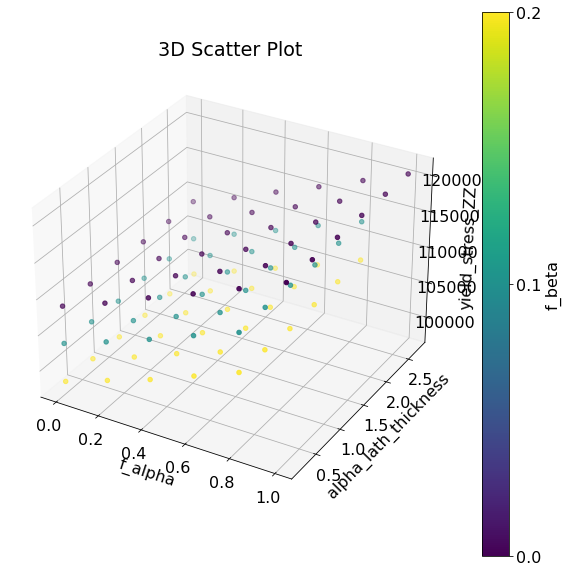

In [126]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the data
sc = ax.scatter(df['f_alpha'], df['lath_thickness'], df['Ez'], c=df['f_beta'])

# Set labels and title
ax.set_xlabel('f_alpha')
ax.set_ylabel('alpha_lath_thickness')
ax.set_zlabel('yield_stress_ZZ')
ax.set_title('3D Scatter Plot')

# Add a colorbar
cbar = fig.colorbar(sc, label='f_beta')
cbar.set_ticks([0.0, 0.1, 0.2])  # Set colorbar ticks to 0.0, 0.1, and 0.2


# Show the plot
plt.show()

# Save the plot to a file
fig.savefig('../data/plot.jpeg')



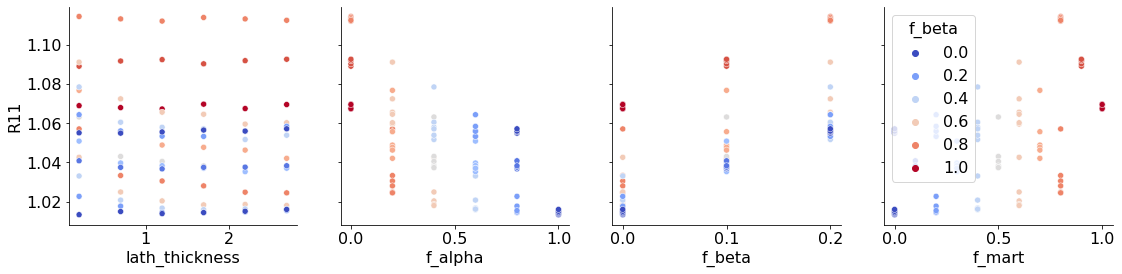

In [127]:
import seaborn as sns

# Create a PairGrid
g = sns.PairGrid(df, y_vars=['R11'], x_vars=['lath_thickness', 'f_alpha', 'f_beta', 'f_mart'], height=4)

# Map a scatter plot to the upper triangle, color points by 'f_beta'
g.map(sns.scatterplot, hue=df['f_mart'], palette='coolwarm')

# Add a legend
plt.legend(title='f_beta', loc='upper left')

# Show the plot
plt.show()

In [164]:
# Polynomial multi-variate regression

# Select appropriate features from the dataset
X = df[['lath_thickness','f_alpha','f_beta']].values

properties = ['yield_stress_ZZ','yield_stress_XX','yield_stress_XY','yield_stress_XZ','Ex','Ez','Gxy','Gxz','Pxz','Pyx']

property = 'yield_stress_XX'
y = df[property].values

# Polynomial features
poly = PolynomialFeatures(degree=5)
X_poly = poly.fit_transform(X)

# Linear Regression model
model = LinearRegression()
model.fit(X_poly, y)

r_sq = model.score(X_poly,y)
print(f"coefficient of determination: {r_sq}")

print(f"intercept: {model.intercept_}")
print(f"slope: {model.coef_}")


# Calculate error with validation data set:

error = []

for index, row in validation_df.iterrows():
    
    print(row['f_alpha'] + row['f_beta'])
    
    new_data = np.array([row['lath_thickness'], row['f_alpha'], row['f_beta']]).reshape(1,-1)  # Example values
    new_data_poly = poly.transform(new_data)


    # Predicting the price
    predicted_y = model.predict(new_data_poly)

    error.append( (predicted_y[0] - row[property]) / row[property] * 100)

print('error_percentage',error)


coefficient of determination: 0.9997138999134799
intercept: 731839151212.3516
slope: [-7.31839150e+11 -6.10594503e+01  1.79489445e+02 -1.39441066e+02
  1.29105533e+02 -1.06701328e+03 -1.09352124e+02 -5.20637843e+01
 -3.83692117e+02  1.90835376e+02 -1.12667208e+02  6.24052520e+02
  1.43815140e+02  1.04209384e+03 -1.79633118e+02 -8.19674577e+01
 -1.93913337e+02  1.49801567e+03 -2.91280587e+02  6.00394340e+01
  4.31135692e+01 -1.99070330e+02 -6.25767104e+01 -2.23558822e+02
  8.42094832e+00  1.96639865e+01 -6.98839144e+02  4.07652020e+02
 -6.86339042e+01 -2.24031948e+01  2.90633371e+02 -2.79124478e+03
  5.87024669e+02 -7.97103338e+01  1.41951227e+01 -5.97525066e+00
  2.53723593e+01  8.75497991e+00  1.90189559e+01  6.81863241e+00
 -1.91570204e+00  6.48488625e+01 -2.74692331e+01  5.48540951e+00
  3.02289317e+00  1.82403493e+02 -2.62514828e+02  1.56730952e+02
 -1.69975089e+01 -5.08160929e+00 -1.09516440e+02  1.74731761e+03
 -5.78046650e+02  1.46147087e+02 -1.80874884e+01  3.05774813e+00]
1.0


In [129]:
## Create Regression model for all independent variables and save them:

from joblib import load

# Select appropriate features from the dataset
X = df[['lath_thickness','f_alpha','f_beta']].values


properties = ['yield_stress_ZZ','yield_stress_XX','yield_stress_XY','yield_stress_XZ','Ex','Ez','Gxy','Gxz','Pxz','Pyx']

for property in properties:
    y = df[property].values

    # Polynomial features
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)

    # Linear Regression model
    model = LinearRegression()
    model.fit(X_poly, y)

    dump(model, f'../data/models_saved/{property}_model.joblib')
    dump(poly, f'../data/models_saved/{property}_poly_transformer.joblib')


In [130]:
hardening = df['yield_stress_hardening_ZZ'].values

for i in range(0,len(hardening[0])):
    # values = [sub_arr[0] for sub_arr in hardening]
    stress_values_this_plastic = [sub_arr[i] for sub_arr in hardening]
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)

    # Linear Regression model
    model = LinearRegression()
    model.fit(X_poly, stress_values_this_plastic)

    dump(model, f'../data/models_saved/hardening_{i}_model.joblib')
    dump(poly, f'../data/models_saved/hardening_{i}_poly_transformer.joblib')



In [131]:
# Read Plastic Strain data and calculate average plastic strain
plastic_strain = df['plastic_strain_ZZ'].values

plastic_strain_average_list = []

for i in range(len(plastic_strain[0])):

    plastic_values_this_strain = [sub_array[i] for sub_array in plastic_strain]
    plastic_strain_average_list.append( sum(plastic_values_this_strain) / len(plastic_values_this_strain) )

# Save plastic_strain_average_list

np.save('../data/plastic_strain_average_list.npy', plastic_strain_average_list)

plastic_strain_average_list

[0.0,
 0.0005000000000000003,
 0.0010000000000000007,
 0.0015000000000000011,
 0.0020000000000000013,
 0.002500000000000002,
 0.0030000000000000022,
 0.0035000000000000027,
 0.004000000000000003,
 0.004500000000000003,
 0.005000000000000004,
 0.0055000000000000005,
 0.0060000000000000045,
 0.0064999999999999945,
 0.007000000000000005,
 0.007499999999999989,
 0.008000000000000005,
 0.008499999999999985,
 0.009000000000000006,
 0.009499999999999982,
 0.010000000000000007,
 0.01049999999999998,
 0.011000000000000001,
 0.01149999999999999,
 0.012000000000000009,
 0.012499999999999976,
 0.012999999999999989,
 0.013500000000000003,
 0.01400000000000001,
 0.014499999999999976,
 0.014999999999999979,
 0.015500000000000012,
 0.01600000000000001,
 0.016499999999999976,
 0.01699999999999997,
 0.01750000000000002,
 0.018000000000000013,
 0.01849999999999998,
 0.018999999999999965,
 0.019500000000000024,
 0.020000000000000014,
 0.020499999999999973,
 0.02099999999999996,
 0.02150000000000003,
 0.02

In [132]:
## Load Model and predict properties for a given microstructure

properties = ['yield_stress_ZZ','yield_stress_XX','yield_stress_XY','yield_stress_XZ','Ex','Ez','Gxy','Gxz','Pxz','Pyx']

pred_prop_dict = {}

for property in properties:

    # Load the model and the transformer
    model = load(f'../data/models_saved/{property}_model.joblib')
    poly = load(f'../data/models_saved/{property}_poly_transformer.joblib')

    # New data
    new_data = np.array([[0.4,0.33,0.09]])  # Example values

    # Transform the new data using the loaded transformer
    new_data_poly = poly.transform(new_data)

    # Use the loaded model to make a prediction
    predicted_y = model.predict(new_data_poly)

    pred_prop_dict[property] = predicted_y[0]


pred_prop_dict['sigma_0'] = []
for i in range(0,len(plastic_strain_average_list)):

    # Load the model and the transformer
    model = load(f'../data/models_saved/hardening_{i}_model.joblib')
    poly = load(f'../data/models_saved/{property}_poly_transformer.joblib')

    # New data
    new_data = np.array([[0.4,0.33,0.09]])  # Example values
    # Transform the new data using the loaded transformer
    new_data_poly = poly.transform(new_data)

    # Use the loaded model to make a prediction
    predicted_y = model.predict(new_data_poly)
    pred_prop_dict['sigma_0'].append(predicted_y[0])

pred_prop_dict['strain_0'] = plastic_strain_average_list

pred_prop_dict

{'yield_stress_ZZ': 803.3896882111566,
 'yield_stress_XX': 846.8072310318186,
 'yield_stress_XY': 436.48102461754905,
 'yield_stress_XZ': 452.0452133966412,
 'Ex': 110656.79332010953,
 'Ez': 107516.61178917253,
 'Gxy': 41845.21825637417,
 'Gxz': 42999.79936776795,
 'Pxz': 0.3331334863555011,
 'Pyx': 0.3088597630353317,
 'sigma_0': [803.3896882111566,
  844.7751594300532,
  879.6728641516909,
  908.7915024629037,
  933.5074800316147,
  955.1026844616606,
  974.4376592094019,
  991.8813539508461,
  1007.5208805944178,
  1021.6090028352372,
  1034.0801049614865,
  1045.211617018266,
  1055.1566043047967,
  1064.025261644421,
  1072.1724802586766,
  1079.4574718906424,
  1086.2154050713275,
  1092.4097750272776,
  1098.042855425949,
  1103.3649469100592,
  1108.122987631828,
  1112.6478630988836,
  1116.7999531698474,
  1120.6170266122997,
  1124.2867150280545,
  1127.5345444413672,
  1130.7134313302463,
  1133.601877035967,
  1136.3151844700396,
  1138.956378399276,
  1141.272667505561,
 

In [133]:
#write material INP:

import importlib
import write_material_inp

importlib.reload(write_material_inp)

write_material_inp.write_inp(pred_prop_dict, '../data/Val_2_interp.inp')

# ## Write Material info in Abaqus inp format:

# #Calculate Hill Parameters from yield stresses
# sigma_0 = pred_prop_dict['yield_stress_ZZ']
# R11 = pred_prop_dict['yield_stress_XX']/sigma_0
# R22 = R11
# R33 = 1
# R12 = pred_prop_dict['yield_stress_XY']/(sigma_0/math.sqrt(3))
# R13 = pred_prop_dict['yield_stress_XZ']/(sigma_0/math.sqrt(3))
# R23 = R13

# hardening_string = ''
# for i in range(len(pred_prop_dict['strain_0'])):
#     hardening_string += f"\n{pred_prop_dict['sigma_0'][i]},{pred_prop_dict['strain_0'][i]}"

# #Write Material info in Abaqus inp format:
# Material_Abaqus_text =f'''**
# *Material, name=Material-1
# *Elastic, type=ENGINEERING CONSTANTS
# {pred_prop_dict['Ex']},{pred_prop_dict['Ex']},{pred_prop_dict['Ez']}, {pred_prop_dict['Pyx']}, {pred_prop_dict['Pxz']}, {pred_prop_dict['Pxz']}, {pred_prop_dict['Gxy']}, {pred_prop_dict['Gxz']}
# {pred_prop_dict['Gxz']},
# *Plastic{hardening_string}
# *Potential
# {R11}, {R22},  {R33},  {R12},  {R12},  {R23}'''


# with open('../data/material.inp', 'w') as f:
#     # Write the string to the file
#     f.write(Material_Abaqus_text)


In [134]:
## Write INP for a CP result
import importlib
import write_material_inp

importlib.reload(write_material_inp)

# Get the row number
# row_number = 0 #CP_HT900
row_number = -1

# Convert the row into a dictionary
row_dict = validation_df.iloc[row_number].to_dict()

row_dict["strain_0"] = row_dict['plastic_strain_ZZ']
row_dict["sigma_0"] = row_dict['yield_stress_hardening_ZZ']


write_material_inp.write_inp(row_dict, '../data/material_second_validation_CP.inp')


In [135]:
row_dict

{'lath_thickness': 0.4,
 'f_alpha': 0.33,
 'f_beta': 0.09,
 'f_mart': 0.58,
 'folder': './temp_102',
 'yield_stress_ZZ': 803.4112765097175,
 'Ez': 107595.68054104714,
 'yield_stress_hardening_ZZ': array([ 803.41127651,  843.80568113,  877.36749386,  905.19050017,
         928.70981106,  949.32677207,  967.83334212,  984.90715001,
        1000.29541961, 1014.10706964, 1026.50047354, 1037.32274439,
        1047.17479388, 1055.84522889, 1063.80929016, 1071.20509172,
        1077.77541222, 1084.16704162, 1089.80620844, 1095.20848008,
        1100.28869816, 1104.80120573, 1109.3376878 , 1113.15058022,
        1116.93065705, 1120.40574076, 1123.4710634 , 1126.67227132,
        1129.1341405 , 1131.76283582, 1134.07444373, 1136.16426605,
        1138.41312086, 1140.03962074, 1141.95910145, 1143.51399216,
        1145.03679438, 1146.6681956 , 1147.83348093, 1149.35858118,
        1150.43195397, 1151.65213281, 1152.87814023, 1153.80056548,
        1155.11182728, 1155.86114431, 1156.92815789, 115

In [136]:
## Linear_Interpolation in 3D unstructured grid

import numpy as np
from scipy.interpolate import griddata

property = 'yield_stress_ZZ'

# Define the points where you know the function values
points = df[['lath_thickness','f_alpha','f_beta']].values # 100 points in 3D
values = df[property].values

# Define the point where you want to interpolate
interp_point = np.array([0.5, 0.0, 0.0])

# Perform the interpolation
interp_value = griddata(points, values, [interp_point], method='linear')

interp_value

# Calculate error with validation data set:

error = []

for index, row in validation_df.iterrows():

    
    interp_point = np.array([row['lath_thickness'], row['f_alpha'], row['f_beta']]).reshape(1,-1)  # Example values
    print(interp_point)
    interp_value = griddata(points, values, [interp_point], method='linear')


    predicted_y = interp_value[0]
    error.append( ( (predicted_y - row[property]) / row[property] ) * 100 )

print('error_percentage',error)


[[1.42 0.88 0.12]]
[[0.85 0.   0.  ]]
[[2.35 0.8  0.1 ]]
[[1.35 1.   0.  ]]
[[0.7  0.61 0.19]]
[[0.4  0.33 0.09]]
error_percentage [array([0.55123634]), array([-0.02096002]), array([0.1187845]), array([0.15614371]), array([0.06342159]), array([0.29283482])]


In [137]:
#RBF Interpolation

import numpy as np
from scipy.interpolate import RBFInterpolator


property = 'yield_stress_ZZ'

# Define the points where you know the function values
points = df[['lath_thickness','f_alpha','f_beta']].values # 100 points in 3D
values = df[property].values

# Define the point where you want to interpolate
rbf = RBFInterpolator(points, values, kernel = 'quintic')


# interp_value = rbf([[2.35, 0.8, 0.1]])

# Calculate error with validation data set:
error = []

for index, row in validation_df.iterrows():

    
    interp_point = np.array([row['lath_thickness'], row['f_alpha'], row['f_beta']]).reshape(1,-1) 
    interp_value = rbf( interp_point )

    predicted_y = interp_value[0]

    print(predicted_y, row[property])

    error.append( ( (predicted_y - row[property]) / row[property] ) * 100 )

print('error_percentage',error)




711.337689435136 710.7296421813581
839.882463084426 839.9223106724927
702.6381191232753 700.382913175343
760.7439514374545 759.1061803477465
729.2819582204049 729.1521211703046
803.7354194052336 803.4112765097175
error_percentage [0.08555253892487631, -0.004744199262281696, 0.32199614032669444, 0.21574993487178257, 0.01780657922135455, 0.040345823489601015]


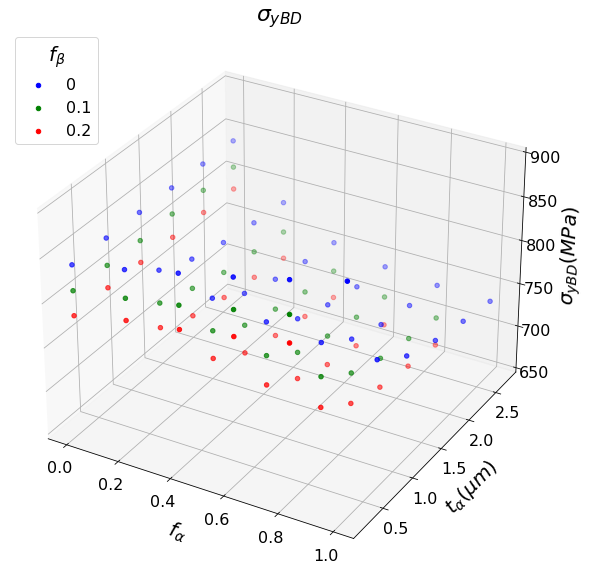

In [138]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({'font.size': 16})


# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Define the colors for each value of f_beta
colors = ['blue', 'green', 'red']  # Modify this list to match your data
labels = ['0', '0.1', '0.2']  # Modify this list to match your data

# Plot the data for each value of f_beta
for i, value in enumerate(df['f_beta'].unique()):
    mask = df['f_beta'] == value
    ax.scatter(df['f_alpha'][mask], df['lath_thickness'][mask], df['yield_stress_ZZ'][mask], color=colors[i], label=labels[i])

# Set labels and title
ax.set_xlabel('$f_{\\alpha }$', fontsize=20, labelpad=10)
ax.set_ylabel('$t_{\\alpha}(\\mu m)$', fontsize=20, labelpad=10)
ax.set_zlabel('$\\sigma_{y BD}(MPa)$', fontsize=20, labelpad=10)
ax.set_title('$\\sigma_{y BD}$', fontsize=22)

ax.set_zlim([650, 900])

# Add a legend with a title
legend = ax.legend(title='$f_\\beta$', loc='upper left')

# Change the font size of the legend title
legend.get_title().set_fontsize('20')

# Show the plot
plt.show()

# Save the plot to a file
fig.savefig('../data/sigma_BD.jpeg', dpi=600)



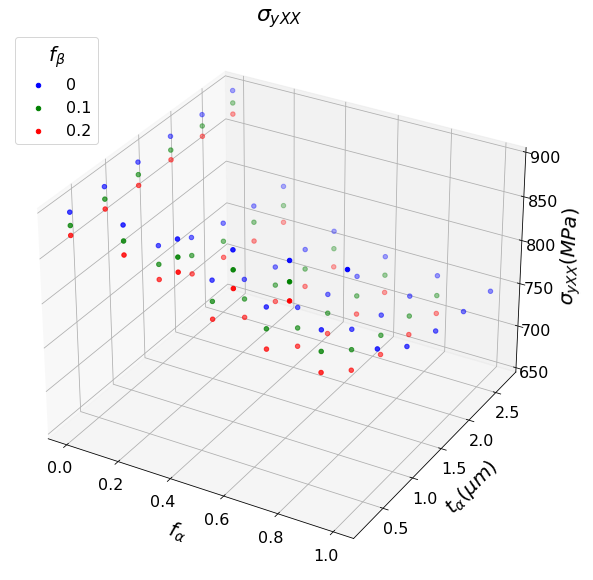

In [139]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({'font.size': 16})


# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Define the colors for each value of f_beta
colors = ['blue', 'green', 'red']  # Modify this list to match your data
labels = ['0', '0.1', '0.2']  # Modify this list to match your data

# Plot the data for each value of f_beta
for i, value in enumerate(df['f_beta'].unique()):
    mask = df['f_beta'] == value
    ax.scatter(df['f_alpha'][mask], df['lath_thickness'][mask], df['yield_stress_XX'][mask], color=colors[i], label=labels[i])

# Set labels and title
ax.set_xlabel('$f_{\\alpha }$', fontsize=20, labelpad=10)
ax.set_ylabel('$t_{\\alpha}(\\mu m)$', fontsize=20, labelpad=10)
ax.set_zlabel('$\\sigma_{y XX}(MPa)$', fontsize=20, labelpad=10)
ax.set_title('$\\sigma_{y XX}$', fontsize=22)

ax.set_zlim([650, 900])

# Add a legend with a title
legend = ax.legend(title='$f_\\beta$', loc='upper left')

# Change the font size of the legend title
legend.get_title().set_fontsize('20')

# Show the plot
plt.show()

# Save the plot to a file
fig.savefig('../data/sigma_XX.jpeg', dpi=600)



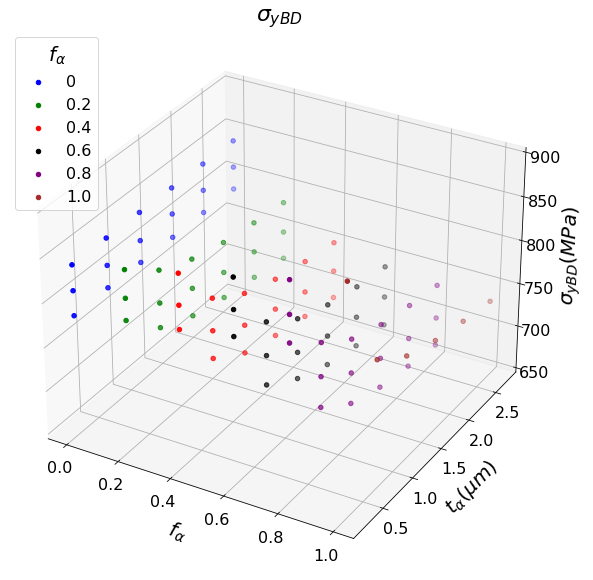

In [140]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({'font.size': 16})


# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Define the colors for each value of f_beta
colors = ['blue', 'green', 'red', 'black', 'purple', 'brown']  # Modify this list to match your data
labels = ['0', '0.2', '0.4', '0.6', '0.8', '1.0']  # Modify this list to match your data

# Plot the data for each value of f_beta
for i, value in enumerate(df['f_alpha'].unique()):
    mask = df['f_alpha'] == value
    ax.scatter(df['f_alpha'][mask], df['lath_thickness'][mask], df['yield_stress_ZZ'][mask], color=colors[i], label=labels[i])

# Set labels and title
ax.set_xlabel('$f_{\\alpha }$', fontsize=20, labelpad=10)
ax.set_ylabel('$t_{\\alpha}(\\mu m)$', fontsize=20, labelpad=10)
ax.set_zlabel('$\\sigma_{y BD}(MPa)$', fontsize=20, labelpad=10)
ax.set_title('$\\sigma_{y BD}$', fontsize=22)

ax.set_zlim([650, 900])

# Add a legend with a title
legend = ax.legend(title='$f_\\alpha$', loc='upper left')

# Change the font size of the legend title
legend.get_title().set_fontsize('20')

# Show the plot
plt.show()

# Save the plot to a file
fig.savefig('../data/sigma_BD_alpha.jpeg', dpi=600)




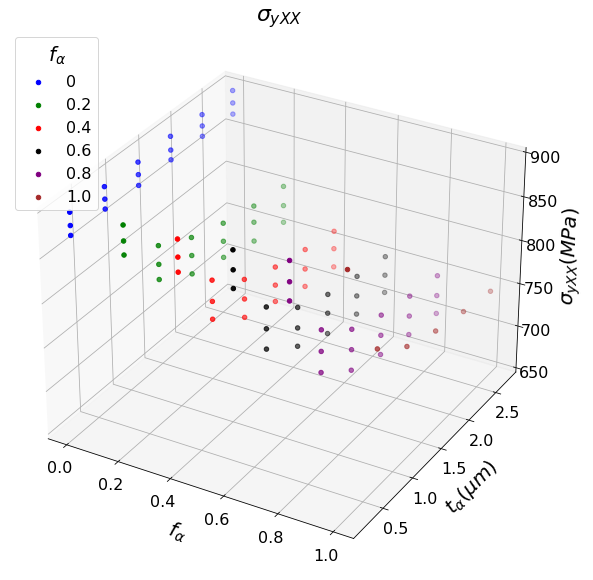

In [141]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({'font.size': 16})


# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Define the colors for each value of f_beta
colors = ['blue', 'green', 'red', 'black', 'purple', 'brown']  # Modify this list to match your data
labels = ['0', '0.2', '0.4', '0.6', '0.8', '1.0']  # Modify this list to match your data

# Plot the data for each value of f_beta
for i, value in enumerate(df['f_alpha'].unique()):
    mask = df['f_alpha'] == value
    ax.scatter(df['f_alpha'][mask], df['lath_thickness'][mask], df['yield_stress_XX'][mask], color=colors[i], label=labels[i])

# Set labels and title
ax.set_xlabel('$f_{\\alpha }$', fontsize=20, labelpad=10)
ax.set_ylabel('$t_{\\alpha}(\\mu m)$', fontsize=20, labelpad=10)
ax.set_zlabel('$\\sigma_{y XX}(MPa)$', fontsize=20, labelpad=10)
ax.set_title('$\\sigma_{y XX}$', fontsize=22)

ax.set_zlim([650, 900])

# Add a legend with a title
legend = ax.legend(title='$f_\\alpha$', loc='upper left')

# Change the font size of the legend title
legend.get_title().set_fontsize('20')

# Show the plot
plt.show()

# Save the plot to a file
fig.savefig('../data/sigma_XX_alpha.jpeg', dpi=600)

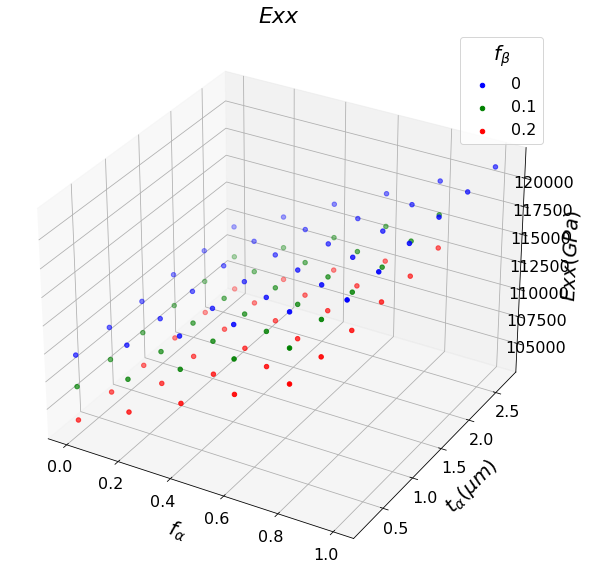

In [142]:


import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({'font.size': 16})


# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Define the colors for each value of f_beta
colors = ['blue', 'green', 'red']  # Modify this list to match your data
labels = ['0', '0.1', '0.2']  # Modify this list to match your data

# Plot the data for each value of f_beta
for i, value in enumerate(df['f_beta'].unique()):
    mask = df['f_beta'] == value
    ax.scatter(df['f_alpha'][mask], df['lath_thickness'][mask], df['Ex'][mask], color=colors[i], label=labels[i])

# Set labels and title
ax.set_xlabel('$f_{\\alpha }$', fontsize=20, labelpad=10)
ax.set_ylabel('$t_{\\alpha}(\\mu m)$', fontsize=20, labelpad=10)
ax.set_zlabel('$Exx(GPa)$', fontsize=20, labelpad=10)
ax.set_title('$Exx}$', fontsize=22)

# ax.set_zlim([650, 1050])

# Add a legend with a title
legend = ax.legend(title='$f_\\beta$')

# Change the font size of the legend title
legend.get_title().set_fontsize('20')

# Show the plot
plt.show()

# Save the plot to a file
fig.savefig('../data/Exx_BD.jpeg', dpi=600)




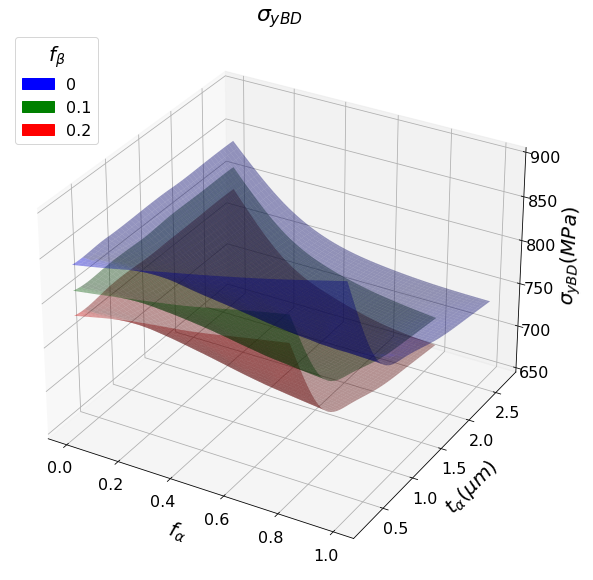

In [143]:
import matplotlib.patches as mpatches

# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Define the colors for each value of f_beta
colors = ['blue', 'green', 'red']  # Modify this list to match your data
labels = ['0', '0.1', '0.2']  # Modify this list to match your data

# Create a list to store the patches for the legend
patches = []

# Plot the data for each value of f_beta
for i, value in enumerate(df['f_beta'].unique()):
    mask = df['f_beta'] == value
    x = df['f_alpha'][mask]
    y = df['lath_thickness'][mask]
    z = df['yield_stress_ZZ'][mask]

    # Create a grid of x and y values
    xi = np.linspace(x.min(), x.max(), 100)
    yi = np.linspace(y.min(), y.max(), 100)
    xi, yi = np.meshgrid(xi, yi)

    # Interpolate z values for the grid
    zi = griddata((x, y), z, (xi, yi), method='cubic')

    # Plot the surface
    ax.plot_surface(xi, yi, zi, color=colors[i], alpha=0.4)

    # Create a patch for the legend
    patches.append(mpatches.Patch(color=colors[i], label=labels[i]))

# Set labels and title
ax.set_xlabel('$f_{\\alpha }$', fontsize=20, labelpad=10)
ax.set_ylabel('$t_{\\alpha}(\\mu m)$', fontsize=20, labelpad=10)
ax.set_zlabel('$\\sigma_{y BD}(MPa)$', fontsize=20, labelpad=10)
ax.set_title('$\\sigma_{y BD}$', fontsize=22)

ax.set_zlim([650, 900])

# Add a legend with a title
legend = ax.legend(handles=patches, title='$f_\\beta$', loc='upper left')

# Change the font size of the legend title
legend.get_title().set_fontsize('20')

# Show the plot
plt.show()

# Save the plot to a file
fig.savefig('../data/sigma_BD._surf.jpeg', dpi=600)



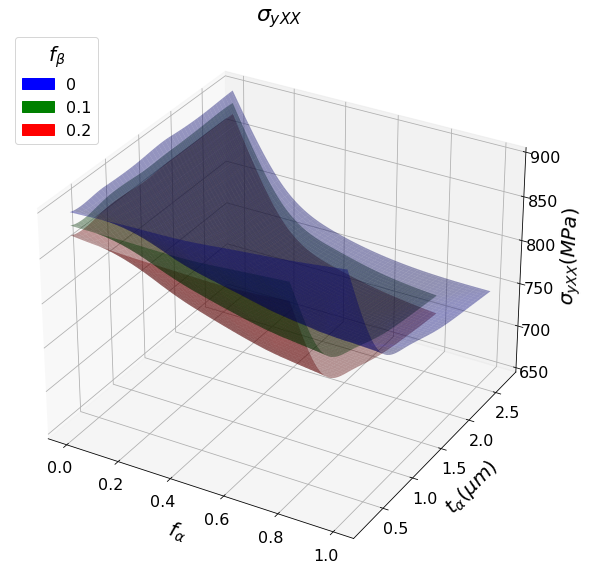

In [144]:
import matplotlib.patches as mpatches

# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Define the colors for each value of f_beta
colors = ['blue', 'green', 'red']  # Modify this list to match your data
labels = ['0', '0.1', '0.2']  # Modify this list to match your data

# Create a list to store the patches for the legend
patches = []

# Plot the data for each value of f_beta
for i, value in enumerate(df['f_beta'].unique()):
    mask = df['f_beta'] == value
    x = df['f_alpha'][mask]
    y = df['lath_thickness'][mask]
    z = df['yield_stress_XX'][mask]

    # Create a grid of x and y values
    xi = np.linspace(x.min(), x.max(), 100)
    yi = np.linspace(y.min(), y.max(), 100)
    xi, yi = np.meshgrid(xi, yi)

    # Interpolate z values for the grid
    zi = griddata((x, y), z, (xi, yi), method='cubic')

    # Plot the surface
    ax.plot_surface(xi, yi, zi, color=colors[i], alpha=0.4)

    # Create a patch for the legend
    patches.append(mpatches.Patch(color=colors[i], label=labels[i]))

# Set labels and title
ax.set_xlabel('$f_{\\alpha }$', fontsize=20, labelpad=10)
ax.set_ylabel('$t_{\\alpha}(\\mu m)$', fontsize=20, labelpad=10)
ax.set_zlabel('$\\sigma_{y XX}(MPa)$', fontsize=20, labelpad=10)
ax.set_title('$\\sigma_{y XX}$', fontsize=22)

ax.set_zlim([650, 900])

# Add a legend with a title
legend = ax.legend(handles=patches, title='$f_\\beta$', loc='upper left')

# Change the font size of the legend title
legend.get_title().set_fontsize('20')

# Show the plot
plt.show()

# Save the plot to a file
fig.savefig('../data/sigma_XX_surf.jpeg', dpi=600)



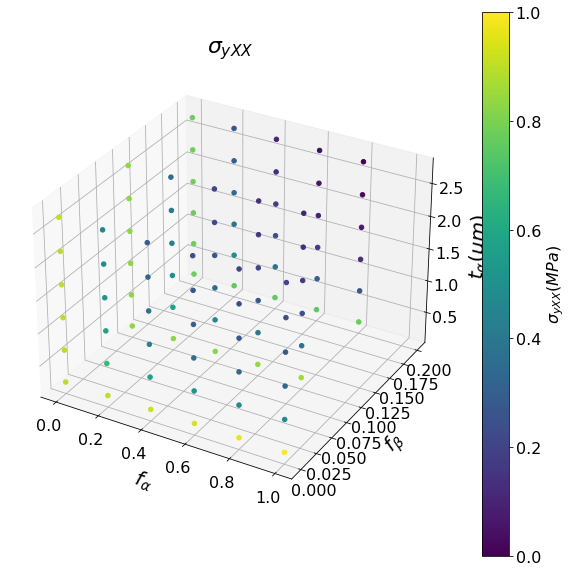

In [145]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Define the colors for each point based on yield_stress_XX
colors = plt.cm.viridis((df['yield_stress_XX'] - df['yield_stress_XX'].min()) / (df['yield_stress_XX'].max() - df['yield_stress_XX'].min()))

# Plot the data
sc = ax.scatter(df['f_alpha'], df['f_beta'], df['lath_thickness'], c=colors, alpha=1)

# Set labels and title
ax.set_xlabel('$f_{\\alpha }$', fontsize=20, labelpad=10)
ax.set_ylabel('$f_{\\beta}$', fontsize=20, labelpad=10)
ax.set_zlabel('$t_{\\alpha}(\\mu m)$', fontsize=20, labelpad=10)
ax.set_title('$\\sigma_{y XX}$', fontsize=22)

# Add a colorbar
fig.colorbar(sc, label='$\\sigma_{y XX}(MPa)$')

# Show the plot
plt.show()

# Save the plot to a file
fig.savefig('../data/sigma_XX_contour.jpeg', dpi=600)



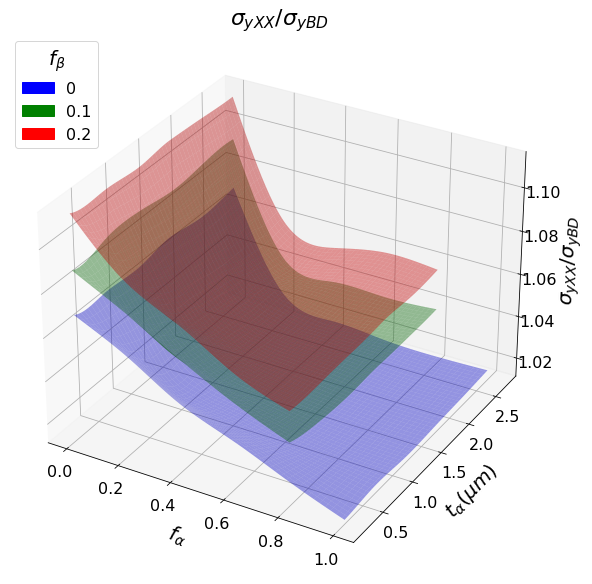

In [146]:
import matplotlib.patches as mpatches

# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Define the colors for each value of f_beta
colors = ['blue', 'green', 'red']  # Modify this list to match your data
labels = ['0', '0.1', '0.2']  # Modify this list to match your data

# Create a list to store the patches for the legend
patches = []

# Plot the data for each value of f_beta
for i, value in enumerate(df['f_beta'].unique()):
    mask = df['f_beta'] == value
    x = df['f_alpha'][mask]
    y = df['lath_thickness'][mask]
    z = df['R11'][mask]

    # Create a grid of x and y values
    xi = np.linspace(x.min(), x.max(), 100)
    yi = np.linspace(y.min(), y.max(), 100)
    xi, yi = np.meshgrid(xi, yi)

    # Interpolate z values for the grid
    zi = griddata((x, y), z, (xi, yi), method='cubic')

    # Plot the surface
    ax.plot_surface(xi, yi, zi, color=colors[i], alpha=0.4)

    # Create a patch for the legend
    patches.append(mpatches.Patch(color=colors[i], label=labels[i]))

# Set labels and title
ax.set_xlabel('$f_{\\alpha }$', fontsize=20, labelpad=10)
ax.set_ylabel('$t_{\\alpha}(\\mu m)$', fontsize=20, labelpad=10)
ax.set_zlabel('$\\sigma_{y XX} / \\sigma_{y BD}$', fontsize=20, labelpad=10)
ax.set_title('$\\sigma_{y XX} / \\sigma_{y BD}$', fontsize=22)

# ax.set_zlim([650, 1050])

# Add a legend with a title
legend = ax.legend(handles=patches, title='$f_\\beta$', loc='upper left')

# Change the font size of the legend title
legend.get_title().set_fontsize('20')

# Show the plot
plt.show()

# Save the plot to a file
fig.savefig('../data/anisotropy_surf.jpeg', dpi=600)